<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica-5-PROCSIN/blob/main/Quest%C3%A3o4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercício 4: Remoção de Ruído com Wavelets e DFT

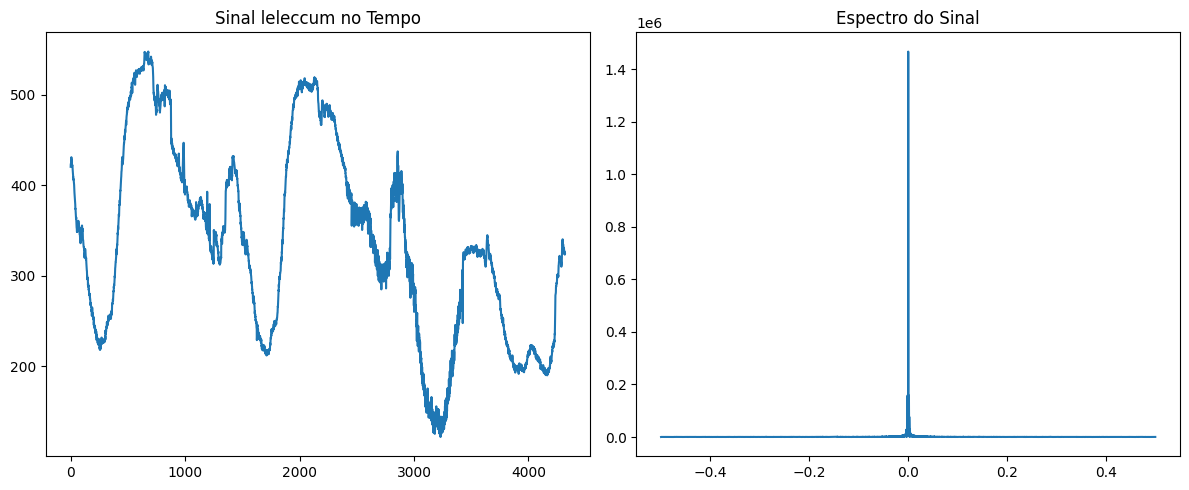

Comentário (a): O sinal apresenta uma componente oscilatória de base com um ruído de alta frequência sobreposto.


In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.fft import fft, fftshift, ifft

# (a) Carregar sinal, plotar tempo e espectro
mat_data = scipy.io.loadmat('leleccum.mat')
# Ajustar a chave correta baseada no arquivo
sig_noise = mat_data['leleccum'].flatten()
N_sig = len(sig_noise)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sig_noise)
plt.title("Sinal leleccum no Tempo")

plt.subplot(1, 2, 2)
spec_lele = np.abs(fftshift(fft(sig_noise)))
freqs_lele = np.linspace(-0.5, 0.5, N_sig)
plt.plot(freqs_lele, spec_lele)
plt.title("Espectro do Sinal")
plt.tight_layout()
plt.show()

print("Comentário (a): O sinal apresenta uma componente oscilatória de base com um ruído de alta frequência sobreposto.")

--- Filtros Daubechies 4 ---
Análise (Lo_D): [-0.010597401785069032, 0.0328830116668852, 0.030841381835560764, -0.18703481171909309, -0.027983769416859854, 0.6308807679298589, 0.7148465705529157, 0.2303778133088965]
Síntese (Lo_R): [0.2303778133088965, 0.7148465705529157, 0.6308807679298589, -0.027983769416859854, -0.18703481171909309, 0.030841381835560764, 0.0328830116668852, -0.010597401785069032]


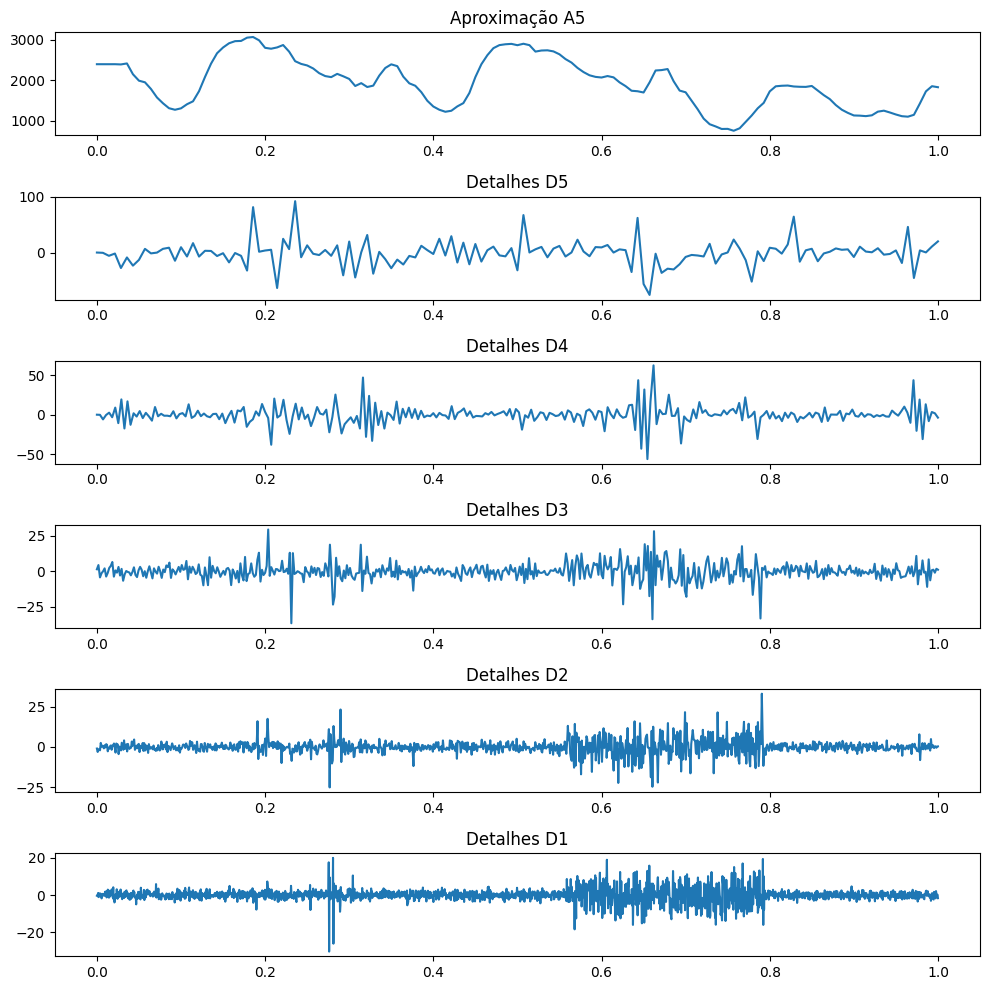

In [ ]:
# (b) Decomposição Daubechies (db4) e filtros
wav_db = pywt.Wavelet('db4')
print("--- Filtros Daubechies 4 ---")
print(f"Análise (Lo_D): {wav_db.dec_lo}")
print(f"Síntese (Lo_R): {wav_db.rec_lo}")

# (c) Transformada de 5 estágios
coeffs_db = pywt.wavedec(sig_noise, 'db4', level=5)

fig, axes = plt.subplots(6, 1, figsize=(10, 10))
axes[0].plot(np.linspace(0, 1, len(coeffs_db[0])), coeffs_db[0])
axes[0].set_title("Aproximação A5")
for i in range(1, 6):
    axes[i].plot(np.linspace(0, 1, len(coeffs_db[i])), coeffs_db[i])
    axes[i].set_title(f"Detalhes D{6-i}")
plt.tight_layout()
plt.show()

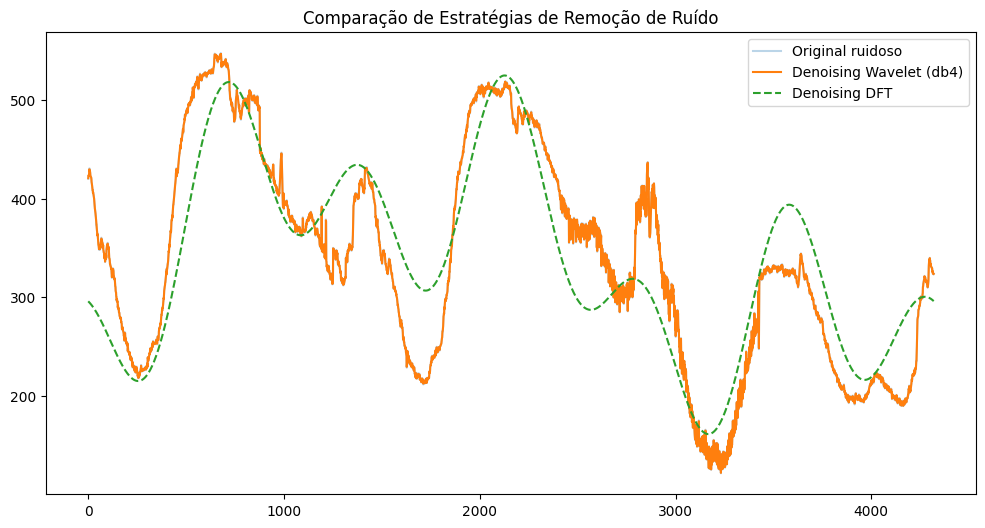

Comentário final: A Wavelet é mais eficaz em preservar transientes locais comparada à DFT, que tende a suavizar o sinal globalmente.


In [ ]:
# (d) Denoising via Thresholding
def wavelet_denoising(data, wavelet='db4', level=5, threshold=0.2):
    coeffs = pywt.wavedec(data, wavelet, level=level)
    # Aplicar limiar nos detalhes (não na aproximação)
    new_coeffs = [coeffs[0]]
    for i in range(1, len(coeffs)):
        new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
    return pywt.waverec(new_coeffs, wavelet)

clean_wav = wavelet_denoising(sig_noise, threshold=0.4)

# (e) Denoising via DFT (Limiar no espectro)
dft_sig = fft(sig_noise)
threshold_dft = np.max(np.abs(dft_sig)) * 0.1
dft_sig_clean = np.where(np.abs(dft_sig) > threshold_dft, dft_sig, 0)
clean_dft = np.real(scipy.fft.ifft(dft_sig_clean))

plt.figure(figsize=(12, 6))
plt.plot(sig_noise, alpha=0.3, label='Original ruidoso')
plt.plot(clean_wav, label='Denoising Wavelet (db4)')
plt.plot(clean_dft, label='Denoising DFT', linestyle='--')
plt.legend()
plt.title("Comparação de Estratégias de Remoção de Ruído")
plt.show()

print("Comentário final: A Wavelet é mais eficaz em preservar transientes locais comparada à DFT, que tende a suavizar o sinal globalmente.")